In [247]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [248]:
import mysql.connector
import pandas as pd

config = {
    'host': '212.227.90.6',
    'user': 'Equipo28',
    'password': 'E1q2u3i4p5o28',
    'database': 'Equip_28'
}

conn = mysql.connector.connect(**config)
cursor = conn.cursor()

cursor.execute("SELECT database();")
db_actual = cursor.fetchone()[0]
print(f"--- Conectado a la base de datos: {db_actual} ---")

cursor.execute("SHOW TABLES;")
tablas = cursor.fetchall()

print("Tablas encontradas:")
for t in tablas:
    print(f" -> {t[0]}")
    globals()[t[0]] = pd.read_sql("SELECT * FROM " + t[0], conn)
    
cursor.close()
conn.close()

--- Conectado a la base de datos: Equip_28 ---
Tablas encontradas:
 -> RRHH


C:\Users\NURIA\AppData\Local\Temp\ipykernel_31352\1330725409.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  globals()[t[0]] = pd.read_sql("SELECT * FROM " + t[0], conn)


 -> vista_duplicados_exactos


In [249]:
df_RRHH=RRHH.copy()

In [250]:
df_RRHH.shape

(740, 21)

### Descripción de las variables del dataset

El conjunto contiene más de **740 registros y 21 columnas** con atributos como edad, ocupación, estado civil, nivel educativo, saldo y variables de contacto con el banco.  

- **ID** (id):identificación única del empleado
- **reason_absence** (razón de absentismo): razón de la ausencia al trabajo. Ausencias certificadas según la Clasificación Internacional de Enfermedades (CIE o  CID en inglés), estratificadas en 21 categorías, y 7 categorías adicionales sin CIE: seguimiento del paciente (22), consulta médica (23), donación de sangre (24), examen de laboratorio (25), ausencia injustificada (26), fisioterapia (27) y consulta odontológica (28).  CATEGÓRICA
- **month_absence** (mes de absentismo): mes en el que el empleado se ausenta del trabajo .  TEMPORAL
- **Day_week** (dia de la semana): Dia de la semana en que se producce la ausencia.  TEMPORAL
- **Seasons** (estación del año): estación en que se produce la ausencia (Verano (1), Otoño (2), Invierno(3), Primavera (4)). TEMPORAL
- **Transportation_expense** (gastos de transporte): gastos de transporte del empleado.  NUMÉRICA
- **Distance_Residence_Work** (distancia): distancia en km entre la residencia y el lugar de trabajo.  NUMÉRICA
- **Service_time** (antigüedad): tiempo de servicio o antigüedad del empleado en la empresa.  NUMÉRICA
- **Age** (edad): edad del empleado.  NUMÉRICA
- **Work_load_Average_day** (carga media diaria): carga de trabajo promedio por día.  NUMÉRICA
- **Hit_target** (cumplimiento del objetivo de desempeño): indica el porcentage alcanzado del objetivo establecido. NUMÉRICA  
- **Disciplinary_failure** (sanción disciplinaria): indica si el empleado ha tenido sanciones disciplinarias (sí=1/no=0). CATEGÓRICA
- **Education** (nivel educativo): nivel educativo del empleado (Bachillerato (1),graduado (2),postgraduado (3),master/doctorado (4)).  CATEGÓRICA
- **Son** (núm de hijos): Número de hijos.  NUMÉRICA
- **Social_drinker** (consumo de alcohol): indica si el empleado consume alcohol (sí=1/no=0).  CATEGÓRICA
- **Social_smoker** (fumador): indica si el empleado consume tabaco (sí=1/no=0). CATEGÓRICA
- **Pet** (mascotas): indica el número de mascotas del empleado.  NUMÉRICA
- **Weight** (peso): peso del empleado. NUMÉRICA
- **Height** (altura): altura del empleado.  NUMÉRICA
- **Body_mass_index** (Indice de masa corporal): relación entre peso y altura del empleado. NUMÉRICA
- **Absenteeism_hours** (horas de absentismo): número de horas de ausencia del empleado. NUMÉRICA

Limitación del dataset:  
Únicamente registra los empleados con absentismo

### Información general del dataset

In [251]:
df_RRHH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       740 non-null    int64 
 1   Reason_absence           740 non-null    int64 
 2   Month_absence            740 non-null    int64 
 3   Day_week                 740 non-null    int64 
 4   Seasons                  740 non-null    int64 
 5   Transportation_expense   740 non-null    int64 
 6   Distance_Residence_Work  740 non-null    int64 
 7   Service_time             740 non-null    int64 
 8   Age                      740 non-null    int64 
 9   Work_load_Average_day    740 non-null    object
 10  Hit_target               740 non-null    int64 
 11  Disciplinary_failure     740 non-null    object
 12  Education                740 non-null    object
 13  Son                      740 non-null    object
 14  Social_drinker           740 non-null    o

In [252]:
df_RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,2,0,6,2,3,235,29,12,48,"275,089",...,1,1,1,0,1,5,88,163,33,0
736,21,0,6,2,3,268,11,8,33,"275,089",...,1,2,0,0,0,0,79,178,25,0
737,4,0,0,3,1,118,14,13,40,"271,219",...,0,1,1,1,0,8,98,170,34,0
738,8,0,0,4,2,231,35,14,39,"271,219",...,0,1,2,1,0,2,100,170,35,0


In [253]:
df1=df_RRHH[df_RRHH['Reason_absence']==0]
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43 entries, 696 to 739
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       43 non-null     int64 
 1   Reason_absence           43 non-null     int64 
 2   Month_absence            43 non-null     int64 
 3   Day_week                 43 non-null     int64 
 4   Seasons                  43 non-null     int64 
 5   Transportation_expense   43 non-null     int64 
 6   Distance_Residence_Work  43 non-null     int64 
 7   Service_time             43 non-null     int64 
 8   Age                      43 non-null     int64 
 9   Work_load_Average_day    43 non-null     object
 10  Hit_target               43 non-null     int64 
 11  Disciplinary_failure     43 non-null     object
 12  Education                43 non-null     object
 13  Son                      43 non-null     object
 14  Social_drinker           43 non-null     objec

In [254]:
missing_values = df_RRHH.isna().sum()
print("El número de valores faltantes es:\n", missing_values)

El número de valores faltantes es:
 ID                         0
Reason_absence             0
Month_absence              0
Day_week                   0
Seasons                    0
Transportation_expense     0
Distance_Residence_Work    0
Service_time               0
Age                        0
Work_load_Average_day      0
Hit_target                 0
Disciplinary_failure       0
Education                  0
Son                        0
Social_drinker             0
Social_smoker              0
Pet                        0
Weight                     0
Height                     0
Body_mass_index            0
Absenteeism_hours          0
dtype: int64


In [255]:
duplicados = df_RRHH.duplicated().sum() #Contar el número total de filas duplicadas (exceptuando la primera ocurrencia)
print(f'El número de duplicados es {duplicados}')

El número de duplicados es 34


In [256]:
df_duplicated= df_RRHH[df_RRHH.duplicated(keep=False)]
df_duplicated

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
91,10,22,12,4,4,361,52,3,28,"261,306",...,0,1,1,1,0,4,80,172,27,8
92,10,22,12,4,4,361,52,3,28,"261,306",...,0,1,1,1,0,4,80,172,27,8
345,34,23,10,3,4,118,10,10,37,"253,465",...,0,1,0,0,0,0,83,172,28,3
348,34,23,10,3,4,118,10,10,37,"253,465",...,0,1,0,0,0,0,83,172,28,3
379,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
383,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
384,3,27,2,6,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
386,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
387,3,27,2,6,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
388,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3


In [257]:
df1=df_RRHH[df_RRHH['Month_absence']==0]
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 737 to 739
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       3 non-null      int64 
 1   Reason_absence           3 non-null      int64 
 2   Month_absence            3 non-null      int64 
 3   Day_week                 3 non-null      int64 
 4   Seasons                  3 non-null      int64 
 5   Transportation_expense   3 non-null      int64 
 6   Distance_Residence_Work  3 non-null      int64 
 7   Service_time             3 non-null      int64 
 8   Age                      3 non-null      int64 
 9   Work_load_Average_day    3 non-null      object
 10  Hit_target               3 non-null      int64 
 11  Disciplinary_failure     3 non-null      object
 12  Education                3 non-null      object
 13  Son                      3 non-null      object
 14  Social_drinker           3 non-null      object

In [258]:
df_RRHH.nunique()

ID                         36
Reason_absence             28
Month_absence              13
Day_week                    5
Seasons                     4
Transportation_expense     24
Distance_Residence_Work    25
Service_time               18
Age                        22
Work_load_Average_day      38
Hit_target                 13
Disciplinary_failure        2
Education                   4
Son                         5
Social_drinker              2
Social_smoker               2
Pet                         6
Weight                     26
Height                     14
Body_mass_index            17
Absenteeism_hours          19
dtype: int64

In [259]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
       'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight',
       'Height', 'Body_mass_index', 'Absenteeism_hours'],
      dtype='object')

In [260]:
cols = ['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
       'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight',
       'Height', 'Body_mass_index', 'Absenteeism_hours'] # Columns to check for unique values

for col in cols:
    print(f"\n{col}:")
    print(df_RRHH[col].unique())


ID:
[14 36  9 28 11 13 34 22 26 20 10 15 17 24  3 18  7  1 30  5  6  2 31 27
 33 23 21 25 12 32 16 29 19  8  4 35]

Reason_absence:
[11 13  6  9 12 19 18  1 10 14  7 28  2 26 23 22 21 24 17  8  5 15  4 25
  3 27 16  0]

Month_absence:
[11  4  7  3  6 12 10  5  8  9  1  2  0]

Day_week:
[2 4 3 6 5]

Seasons:
[4 3 1 2]

Transportation_expense:
[155 118 228 225 289 369 179 300 260 361 291 246 330 279 235 157 189 388
 184 248 378 268 233 231]

Distance_Residence_Work:
[12 13 14 26 36 17 10 50 52 31 22 25 51 16  5 11 27 20 29 15 42 49 48 35
 45]

Service_time:
[14 18 16  9 13 12 10 11  3 17  4  6  7  8  1 29 24 15]

Age:
[34 50 58 28 33 31 37 30 43 36 40 41 38 39 29 48 27 47 32 49 46 53]

Work_load_Average_day:
['284,031' '239,409' '264,604' '230,290' '222,196' '377,550' '280,549'
 '261,306' '265,017' '237,656' '326,452' '239,554' '205,917' '306,345'
 '343,253' '294,217' '253,957' '241,476' '275,312' '330,061' '378,884'
 '251,818' '268,519' '313,532' '246,288' '275,089' '253,465' '244,387'

**Observaciones generales:**
- No se observan valores nulos (NaN)
- Número de duplicados
- Hay 43 registros con Reason_absence=0 (no se conoce la razón)
- Hay 3 resgistros con Month_absence=0 (incongruente)
- La razón de absentismo es numérica en el dataset, pero en realidad corresponde a un valor categórico
- Mes/Dia/Estación de absentismo es numérica pero corresponde a un valor temporal o categórico
- Variables numéricas:  
    a) Transportation_expense, Distance_Residence_Work, Service_time, Age, Hit_target, Weight, Height, Body_mass_index, Absenteeism_hours  
    b) Pet y Son no lo son y deberian serlo
- Variables categóricas:  
    a) Education
    b) Reason_absence deberia serlo

**ANALISIS DEMOGRÁFICO INICIAL**

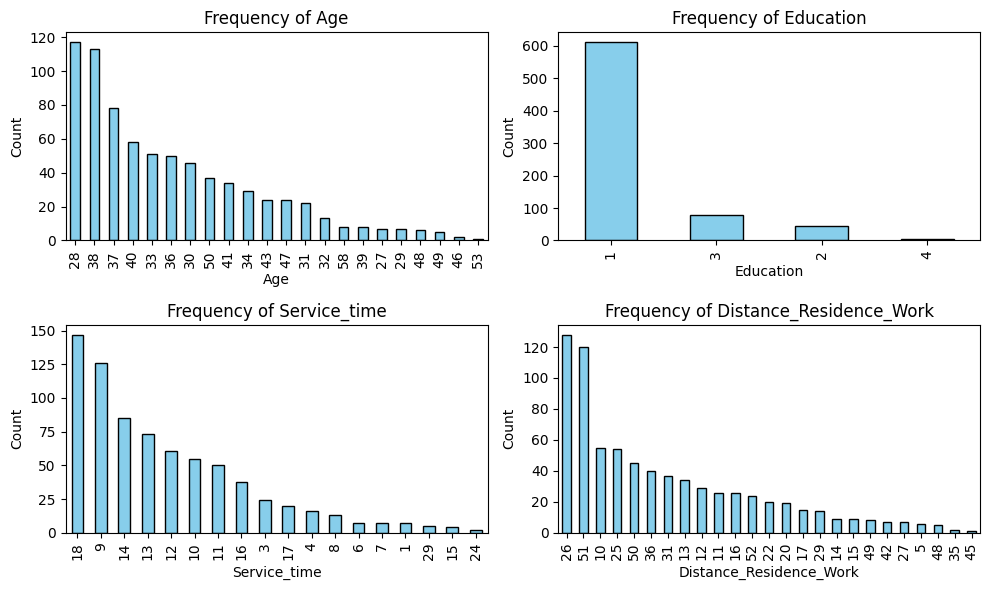

In [261]:
cols = ["Age","Education", 'Service_time', 'Distance_Residence_Work']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

axes = axes.flatten()  # 👈 convertir a lista de 4 posiciones

for i, col in enumerate(cols):
    freq = df_RRHH[col].value_counts()
    freq.plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    
    axes[i].set_title(f'Frequency of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

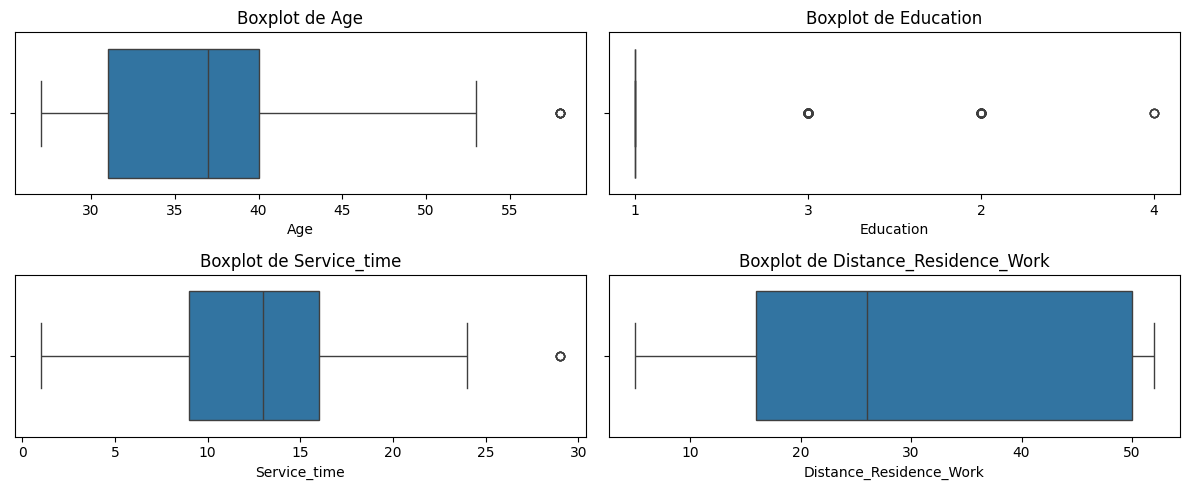

In [262]:
cols = ["Age","Education", 'Service_time', 'Distance_Residence_Work']

fig, axes = plt.subplots(2, 2, figsize=(12, 5))  # 2 filas, 2 columnas
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df_RRHH[col], ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

In [263]:
df_RRHH[cols].dtypes

Age                         int64
Education                  object
Service_time                int64
Distance_Residence_Work     int64
dtype: object

In [264]:
# Comprobamos que hay outliers usando método IQR:
cols = ["Age", 'Service_time', 'Distance_Residence_Work'] #Education es object
for var in cols:

    q1, q3 = np.percentile(df_RRHH[var], [25, 75])
    iqr=q3-q1
    lim_inferior = q1 - 1.5 * iqr
    lim_superior = q3 + 1.5 * iqr
    print(f"\nEn la variable {var}")
    print(f"Q1:{q1}, Q3:{q3}, IQR: {iqr}")
    print(f"Limite inferior: {lim_inferior}")
    print(f"Limite superior: {lim_superior}")

outliers_iqr_var= df_RRHH[var][(df_RRHH[var] < lim_inferior) | (df_RRHH[var] > lim_superior)]
print(f"\nOutliers using IQR method: \n{outliers_iqr_var}")


En la variable Age
Q1:31.0, Q3:40.0, IQR: 9.0
Limite inferior: 17.5
Limite superior: 53.5

En la variable Service_time
Q1:9.0, Q3:16.0, IQR: 7.0
Limite inferior: -1.5
Limite superior: 26.5

En la variable Distance_Residence_Work
Q1:16.0, Q3:50.0, IQR: 34.0
Limite inferior: -35.0
Limite superior: 101.0

Outliers using IQR method: 
Series([], Name: Distance_Residence_Work, dtype: int64)


**Observaciones:**  
1) Age: serán outliers por debajo de 17.5 (raro) y por encima de 53.5
2) Antiguedad: seran outliers sólo por encima de 26.5 porque un valor negativo no tiene sentido
3)Distancia al trabajo: solo será relevante los outliers por encima de 101km porque el valor negativo no tiene sentido

**ANALISIS ABSENTISMO INICIAL**

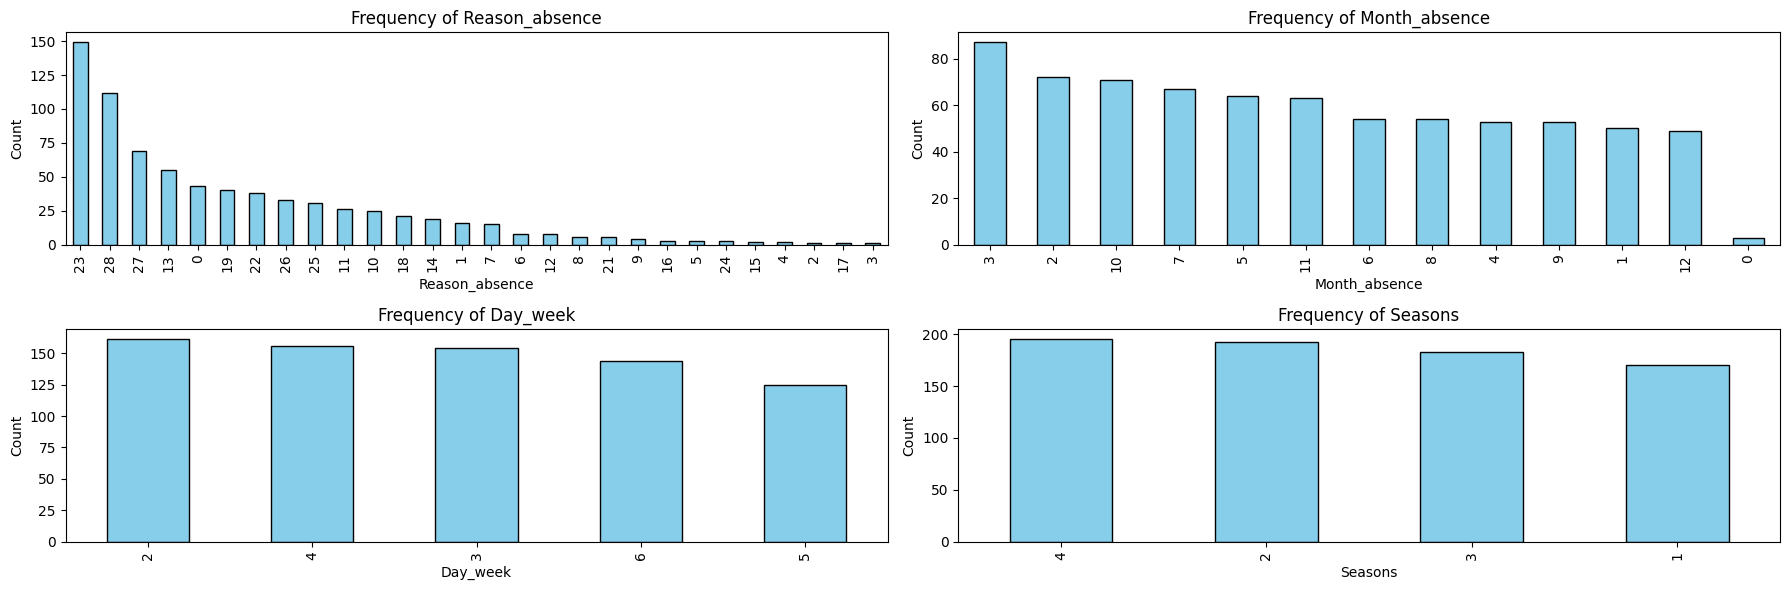

In [265]:
cols = ['Reason_absence', 'Month_absence', 'Day_week', 'Seasons']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 6))

axes = axes.flatten()  # 👈 convertir a lista de 4 posiciones

for i, col in enumerate(cols):
    freq = df_RRHH[col].value_counts()
    freq.plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    
    axes[i].set_title(f'Frequency of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

**OBSERVACIONES:**  
1.- la mayor razón de absentismo es la consuslta médic(23),seguida de la visita al dentista (28) y la fisioterapia (27)  
2.- El mes de marzo concentra el mayor número se ausencias al trabajo. **Se debe eliminar el mes cero**   
3.- El dia de menor absentismo es el jueves  
4.- Apenas hay diferencia en absentismo entre las diferntes estaciones del año  

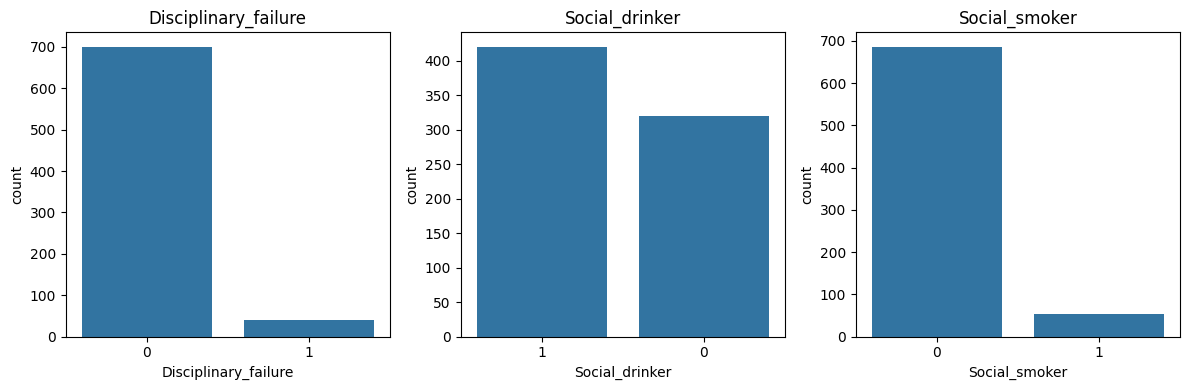

In [266]:
binary_cols = ['Disciplinary_failure', 'Social_drinker', 'Social_smoker']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, col in enumerate(binary_cols):
    sns.countplot(x=df_RRHH[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Descripción estadística de las variables numéricas del dataset

In [267]:
df_RRHH.describe()

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Hit_target,Weight,Height,Body_mass_index,Absenteeism_hours
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000
mean,18.017568,19.216216,6.324324,3.914865,2.544595,221.329730,29.631081,12.554054,36.450000,94.587838,79.035135,172.114865,26.677027,6.924324
std,11.021247,8.433406,3.436287,1.421675,1.111831,66.952223,14.836788,4.384873,6.478772,3.779313,12.883211,6.034995,4.285452,13.330998
min,1.000000,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,81.000000,56.000000,163.000000,19.000000,0.000000
25%,9.000000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,93.000000,69.000000,169.000000,24.000000,2.000000
50%,18.000000,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,95.000000,83.000000,170.000000,25.000000,3.000000
75%,28.000000,26.000000,9.000000,5.000000,4.000000,260.000000,50.000000,16.000000,40.000000,97.000000,89.000000,172.000000,31.000000,8.000000
max,36.000000,28.000000,12.000000,6.000000,4.000000,388.000000,52.000000,29.000000,58.000000,100.000000,108.000000,196.000000,38.000000,120.000000


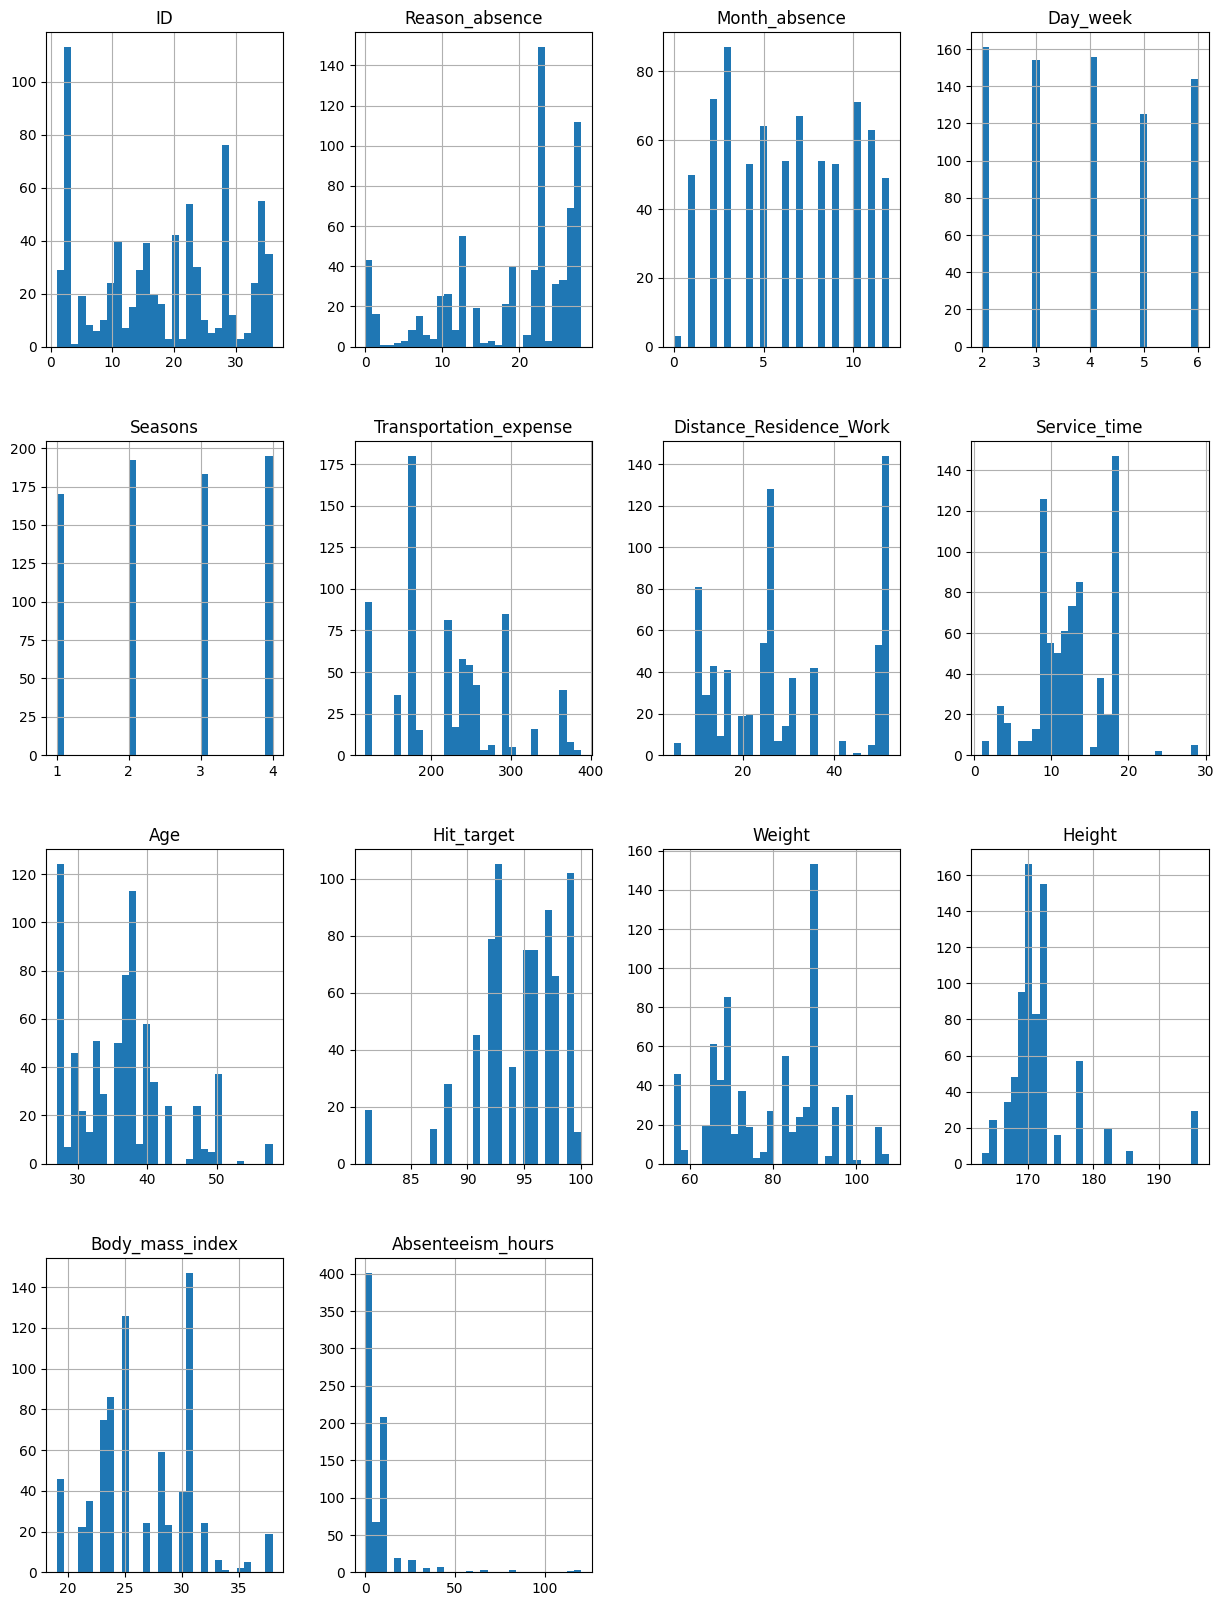

In [268]:
# Histograma de cada variable numèrica
df_RRHH.hist(bins=30, figsize=(15, 20))
plt.show()

### Descripción estadística para variables categoricas 

In [269]:
df_RRHH.select_dtypes(include='object').columns

Index(['Work_load_Average_day', 'Disciplinary_failure', 'Education', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet'],
      dtype='object')

**Observación:**  
1) 'Work_load_Average_day' deberia ser numérica y no la tendremos en cuneta para calcular la moda

In [270]:
cols = ['Disciplinary_failure', 'Education',
        'Son', 'Social_drinker', 'Social_smoker', 'Pet']

df_RRHH[cols].mode().iloc[0]


Disciplinary_failure    0
Education               1
Son                     0
Social_drinker          1
Social_smoker           0
Pet                     0
Name: 0, dtype: object

**Observaciones:**  
1) la mayoria no tienen sancion disciplinaria
2) la mayoria no tienen estudios superiores
3) a mayoria no tienen mascotas
4) la mayoria son bebedores sociales y no fumadores